In [1]:
import yfinance as yf #from yahoo finance

In [2]:
sp500 = yf.Ticker("^GSPC")

In [3]:
sp500 = sp500.history(period = "max")

In [4]:
sp500 #original sp500 data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,7548.779785,7564.959961,7508.680176,7511.350098,5286210000,0.0,0.0
2026-06-17 00:00:00-04:00,7524.500000,7532.169922,7402.609863,7420.100098,5883740000,0.0,0.0
2026-06-18 00:00:00-04:00,7487.359863,7511.069824,7468.319824,7500.580078,9061110000,0.0,0.0


In [5]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-06-09 00:00:00-04:00', '2026-06-10 00:00:00-04:00',
               '2026-06-11 00:00:00-04:00', '2026-06-12 00:00:00-04:00',
               '2026-06-15 00:00:00-04:00', '2026-06-16 00:00:00-04:00',
               '2026-06-17 00:00:00-04:00', '2026-06-18 00:00:00-04:00',
               '2026-06-22 00:00:00-04:00', '2026-06-23 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=24735, freq=None)

In [6]:
del sp500["Dividends"]
del sp500["Stock Splits"]
#deletes the useless columns

<Axes: xlabel='Date'>

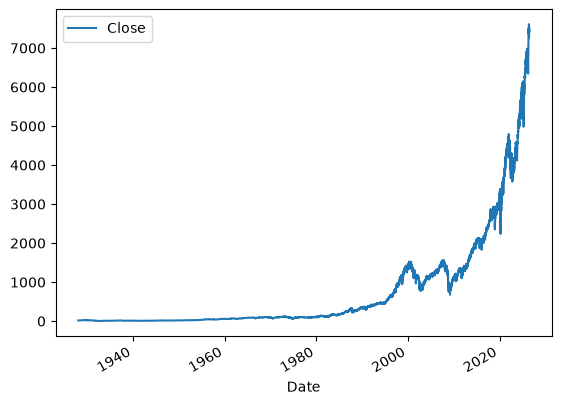

In [7]:
sp500.plot.line(y = "Close", use_index = True)

In [8]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)
#create a column with tomorrow's price; shifts the close column back one day
#tomorrow's price is the close price of the next day

In [9]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
#set up target based on tomorrow's price (what we're trying to predict)
#is tomorrow's price greater than today's price and returns a boolean
#astype transforms the bool into an int

In [10]:
sp500 = sp500.loc["1990-01-01":].copy()
#start learning with recent market data/remove data from before 1990

In [11]:
sp500 #1 when price went up and 0 when price went down

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,7548.779785,7564.959961,7508.680176,7511.350098,5286210000,7420.100098,0
2026-06-17 00:00:00-04:00,7524.500000,7532.169922,7402.609863,7420.100098,5883740000,7500.580078,1
2026-06-18 00:00:00-04:00,7487.359863,7511.069824,7468.319824,7500.580078,9061110000,7472.790039,0


In [12]:
from sklearn.ensemble import RandomForestClassifier
'''trains a bunch of decision trees with random parameters and averaging out the results 
from each decision tree + resistant to overfitting
open price is not linearily correlated to target price
can pick up non linear relationships
'''

model = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1)
'''n estimators: number of trees we want to train (more = higher accuracy)
min samples split: prevents overfitting. higher = less accurate but less overfitting
random state: if we run the same numbers more than once, the results will be the same 
(helps improve error during testing)
'''

train = sp500.iloc[:-100]
'''
model should actually learn to predict the stock price instead of basing its predictions off
information about the future
'''

test = sp500.iloc[-100:]
'''
put all the rows except the last 100 rows in the training set. the last 100 rows will be
used to test
'''

predictors = ["Close", "Volume", "Open", "High", "Low"]
#all the columns used to train the target
#do not use target or tomorrow columns because the model will know the future

#fit the model and try to predict the target
model.fit(train[predictors], train["Target"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [13]:
from sklearn.metrics import precision_score
predictions = model.predict(test[predictors])
#when the target was a 1, did the price really go up

In [14]:
predictions #currently a numpy array

array([0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [15]:
import pandas as pd
predictions = pd.Series(predictions, index = test.index)

In [16]:
predictions #now a legible series

Date
2026-01-29 00:00:00-05:00    0
2026-01-30 00:00:00-05:00    1
2026-02-02 00:00:00-05:00    0
2026-02-03 00:00:00-05:00    1
2026-02-04 00:00:00-05:00    1
                            ..
2026-06-16 00:00:00-04:00    0
2026-06-17 00:00:00-04:00    0
2026-06-18 00:00:00-04:00    0
2026-06-22 00:00:00-04:00    0
2026-06-23 00:00:00-04:00    0
Length: 100, dtype: int64

In [17]:
precision_score(test["Target"], predictions)
#calculate how often the model predicted correctly

0.5434782608695652

In [18]:
combined = pd.concat([test["Target"], predictions], axis = 1)
#combine actual values with predicted values to plot our tester
#each input is a column

<Axes: xlabel='Date'>

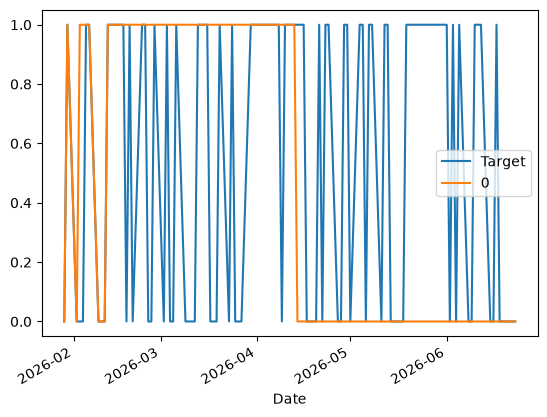

In [19]:
combined.plot()
#0 is prediction
#1 is actual market

In [20]:
def predict(train, test, predictors, model):
    '''
    creating a backtesting algorithm: currently only testing past 100 lines
    prediction function to train model
    fitting of model using predictors
    test and predict
    combine model into series (preds)
    return combined dataframe with actual values
    '''
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors]) 
    preds = pd.Series(preds, index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds], axis = 1)
    return combined

In [21]:
def backtest(data, model, predictors, start=2500, step-250): 
    #take 10 years of data and train the first model. 
    #step of 250: ~250 working days per year for model to train with
    

SyntaxError: invalid syntax (697279856.py, line 1)